In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [30]:
# Load your dataset
data = pd.read_csv('FloridaBikeRentals.csv')  

In [31]:
data.shape

(8760, 14)

In [32]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Date                       8760 non-null   str    
 1   Rented Bike Count          8760 non-null   int64  
 2   Hour                       8760 non-null   int64  
 3   Temperature(�C)            8760 non-null   float64
 4   Humidity(%)                8760 non-null   int64  
 5   Wind speed (m/s)           8760 non-null   float64
 6   Visibility (10m)           8760 non-null   int64  
 7   Dew point temperature(�C)  8760 non-null   float64
 8   Solar Radiation (MJ/m2)    8760 non-null   float64
 9   Rainfall(mm)               8760 non-null   float64
 10  Snowfall (cm)              8760 non-null   float64
 11  Seasons                    8760 non-null   str    
 12  Holiday                    8760 non-null   str    
 13  Functioning Day            8760 non-null   str    
dtypes: 

### missing valie 
##### Check for null values in any columns and handle the missing values
##### no missing value && null value

In [33]:
# Convert Date columns to Date format and extract day, month, day of week, and weekdays/weekend from date column
data['Date'].info()
data['Date'] = pd.to_datetime(data['Date'], format='%d/%m/%Y')
 

<class 'pandas.Series'>
RangeIndex: 8760 entries, 0 to 8759
Series name: Date
Non-Null Count  Dtype
--------------  -----
8760 non-null   str  
dtypes: str(1)
memory usage: 68.6 KB


In [34]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[us]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(�C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(�C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  Seasons                    8760 non-null   str           
 12  Holiday          

In [35]:
data['day'] = data['Date'].dt.day
data['year'] = data['Date'].dt.year
data['month'] = data['Date'].dt.month
data['weekday'] = data['Date'].dt.day_name()
data['is_weekend'] = data['Date'].dt.dayofweek >= 5
data.head()

,Date,Rented Bike Count,Hour,Temperature(�C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(�C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day,day,year,month,weekday,is_weekend
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,2017,12,Friday,False
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,2017,12,Friday,False
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes,1,2017,12,Friday,False
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,2017,12,Friday,False
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes,1,2017,12,Friday,False


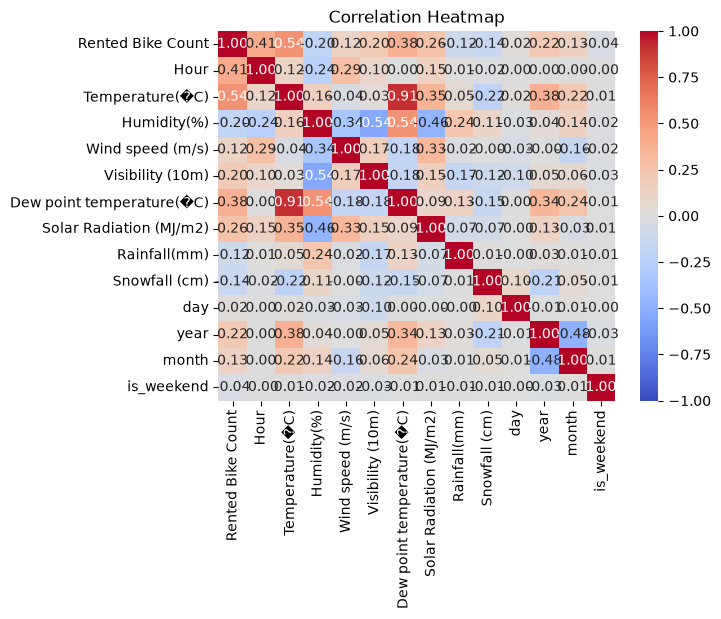

In [36]:
# Check correlation of features using heatmap
corr = data.corr(numeric_only=True)
# print(corr)
plt.Figure(figsize=(15,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

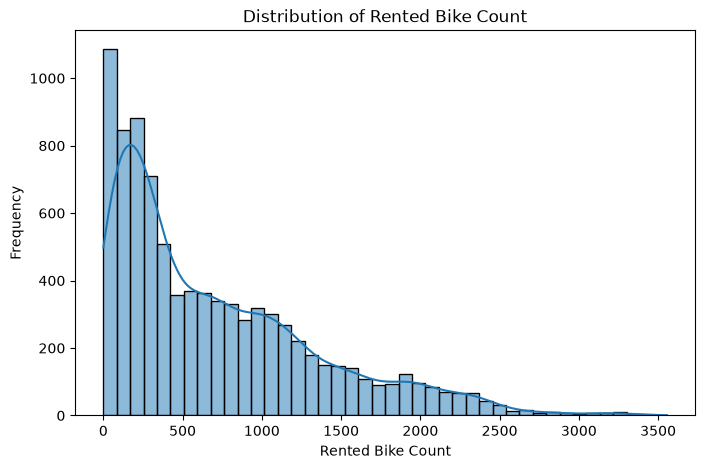

In [37]:
# Plot the distribution plot of Rented Bike Count
plt.figure(figsize=(8, 5))
sns.histplot(data['Rented Bike Count'], kde=True)
plt.title('Distribution of Rented Bike Count')
plt.xlabel('Rented Bike Count')
plt.ylabel('Frequency')
plt.show()

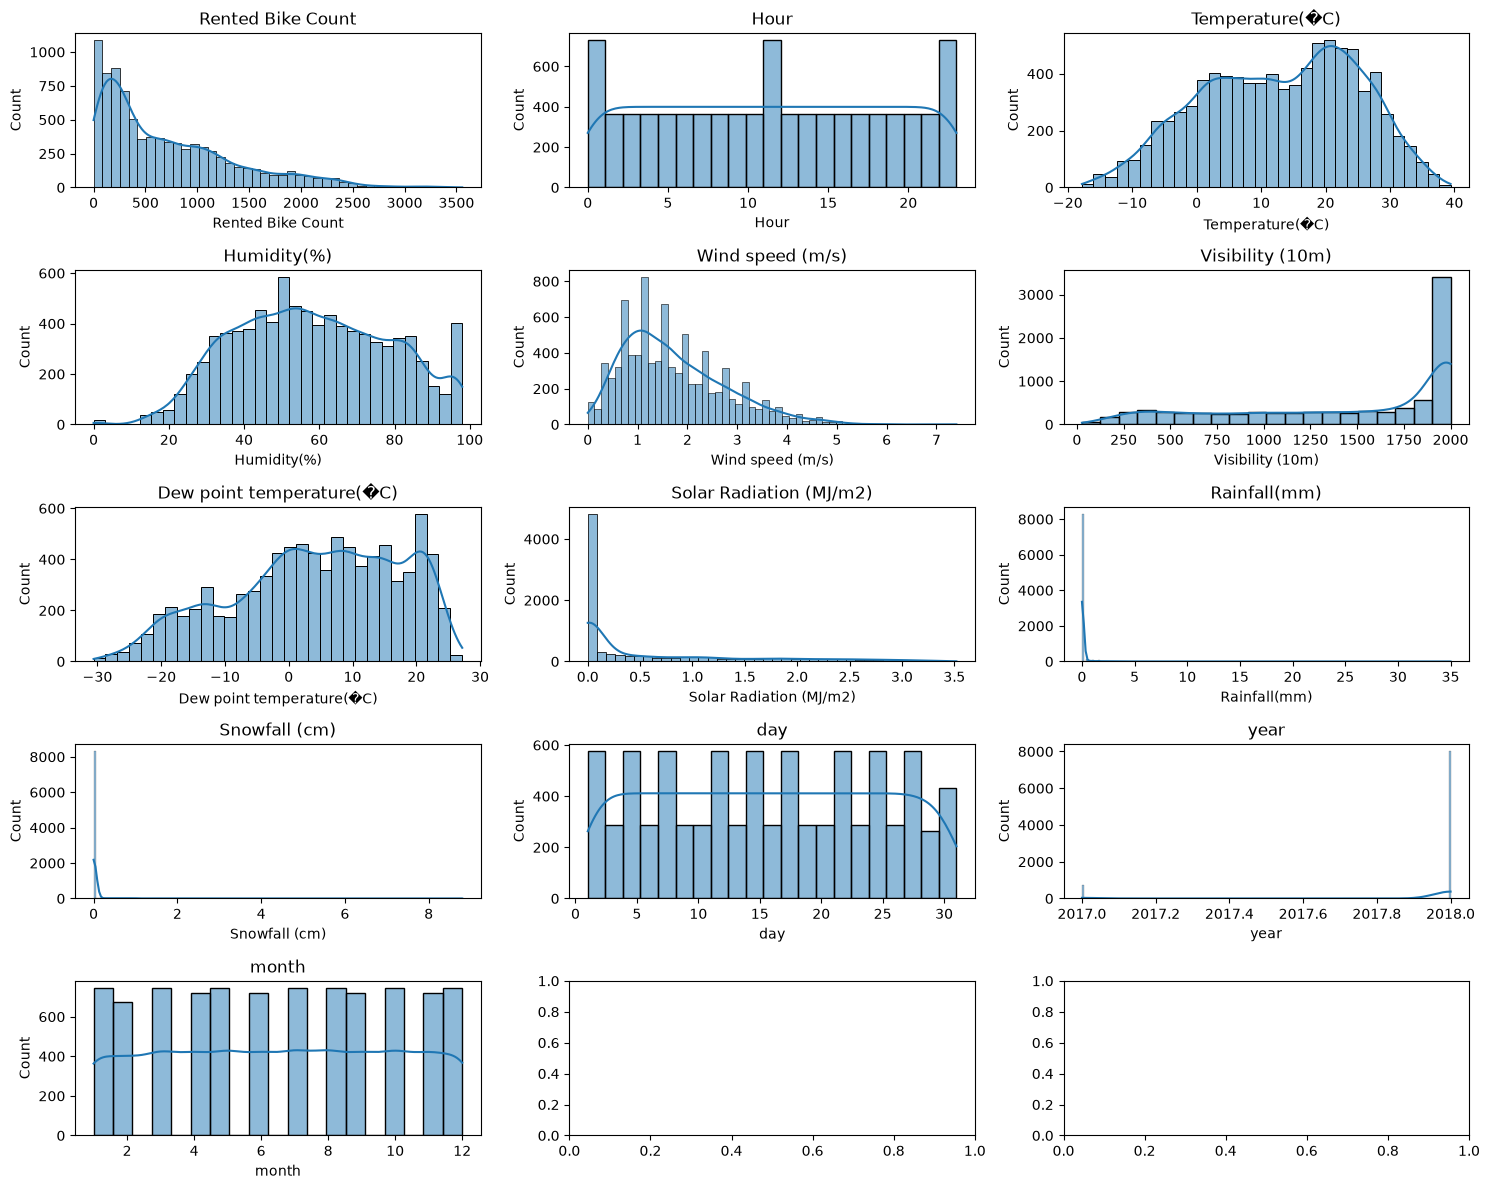

In [38]:
num_cols = data.select_dtypes(include='number').columns
fig, axes = plt.subplots(nrows=(len(num_cols)+2)//3, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Index(['Seasons', 'Holiday', 'Functioning Day', 'weekday'], dtype='str')


/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_13304/664333767.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns


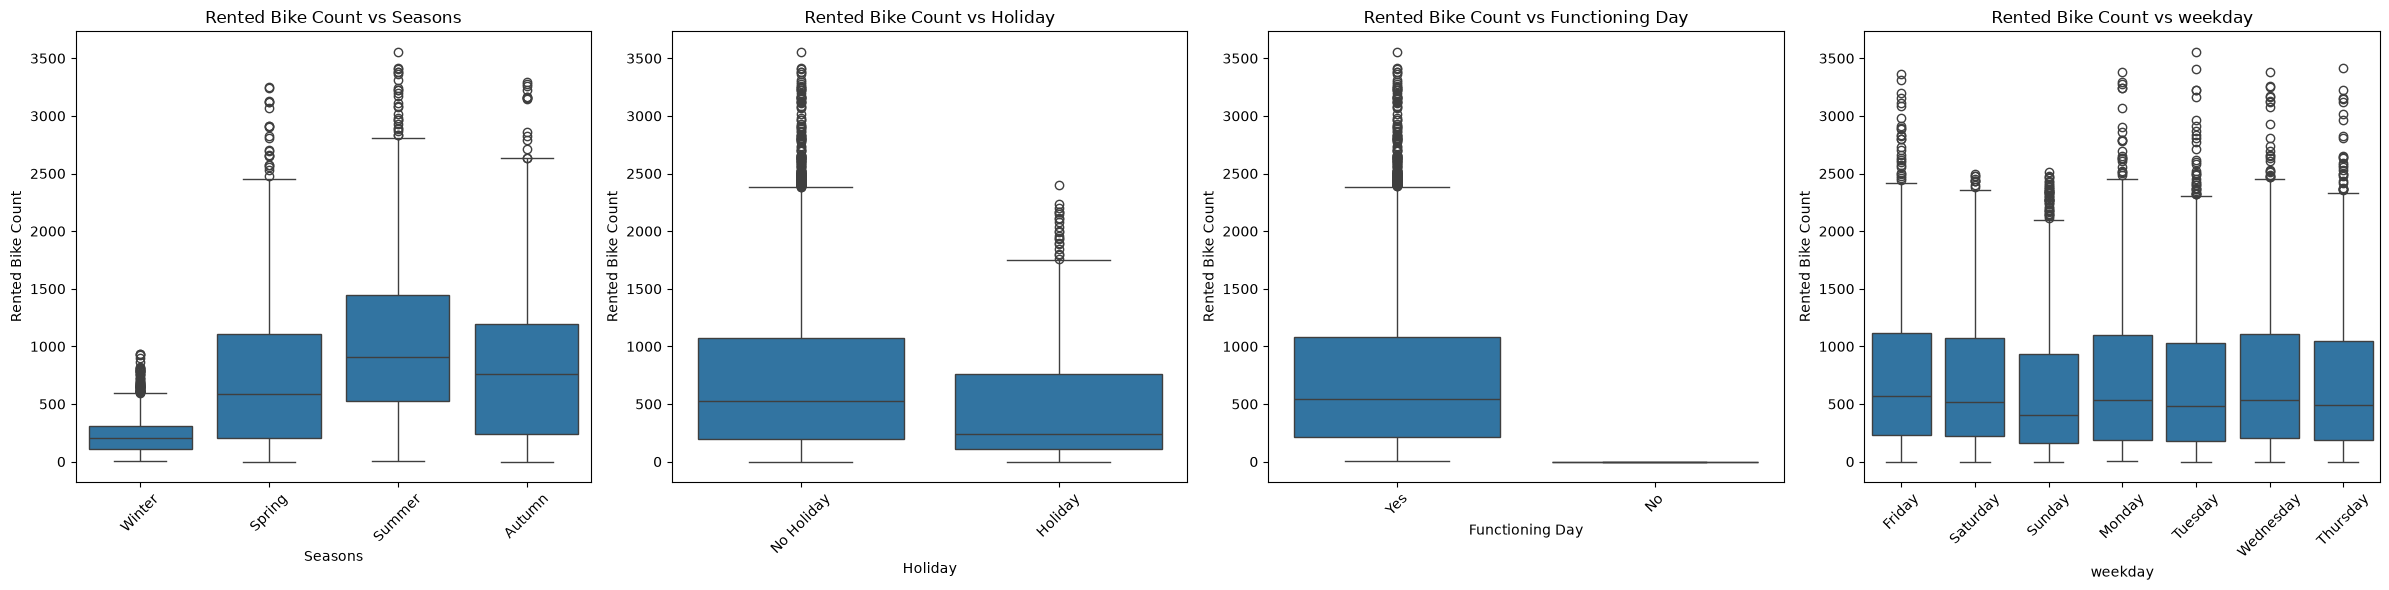

In [39]:
# Plot the box plot of Rented Bike Count against all the categorical features (Hint: Categorical features on X-axis and  Rented Bike Count on Y-axis)
cat_cols = data.select_dtypes(include='object').columns
print(cat_cols)
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(6*len(cat_cols), 6))

for i, col in enumerate(cat_cols):
    sns.boxplot(x=data[col], y=data['Rented Bike Count'], ax=axes[i])
    axes[i].set_title(f'Rented Bike Count vs {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

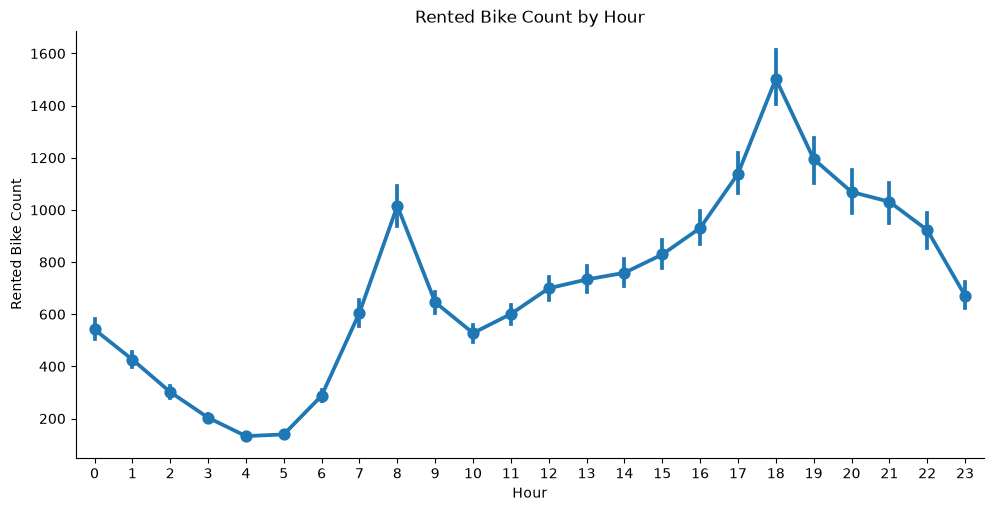

In [40]:
sns.catplot(x='Hour', y='Rented Bike Count', data=data, kind='point', height=5, aspect=2)
plt.title('Rented Bike Count by Hour')
plt.show()

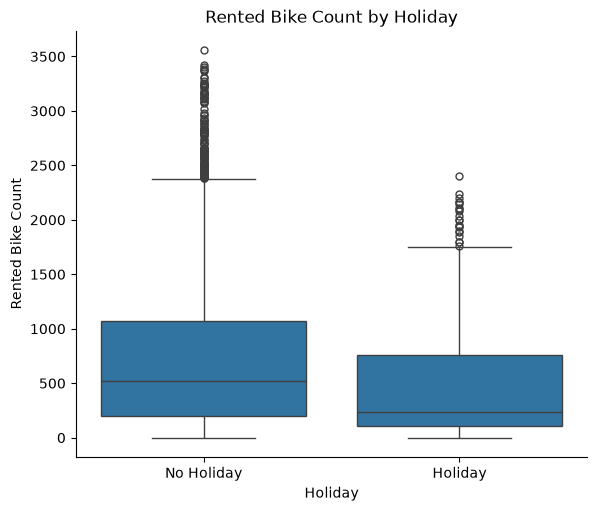

In [41]:
sns.catplot(x='Holiday', y='Rented Bike Count', data=data, kind='box', height=5, aspect=1.2)
plt.title('Rented Bike Count by Holiday')
plt.show()

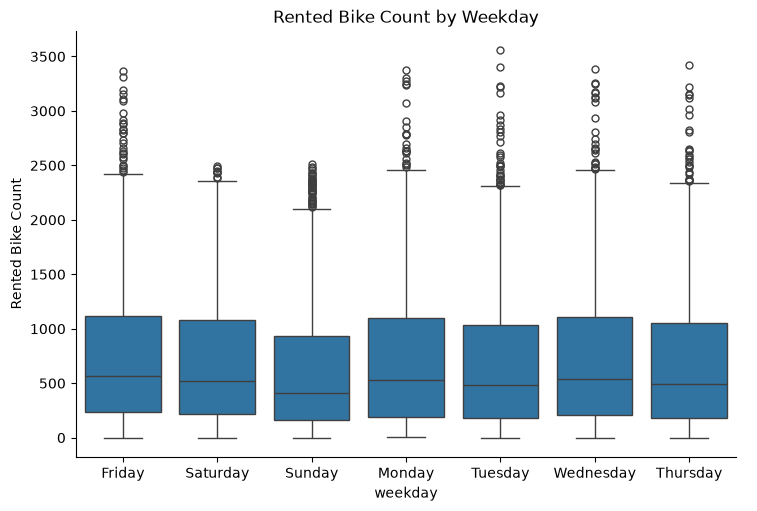

In [42]:
sns.catplot(x='weekday', y='Rented Bike Count', data=data, kind='box', height=5, aspect=1.5)
plt.title('Rented Bike Count by Weekday')
plt.show()

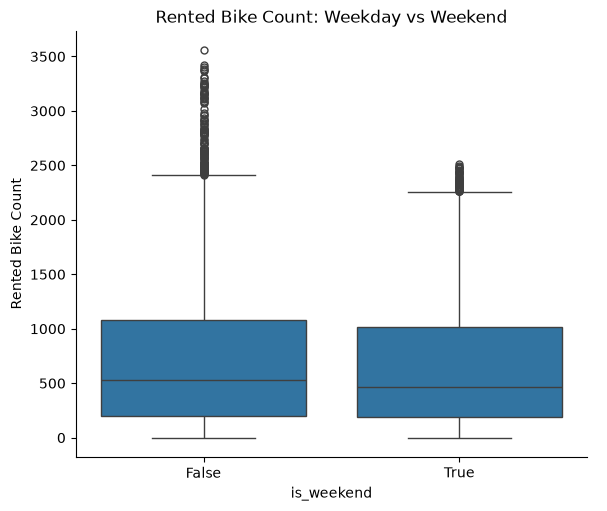

In [43]:
sns.catplot(x='is_weekend', y='Rented Bike Count', data=data, kind='box', height=5, aspect=1.2)
plt.title('Rented Bike Count: Weekday vs Weekend')
plt.show()

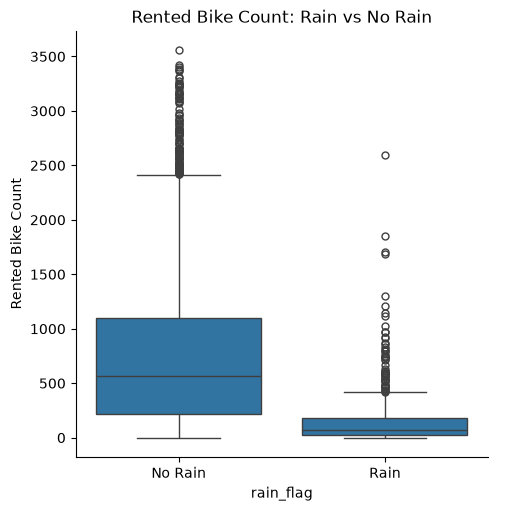

In [44]:
data['rain_flag'] = data['Rainfall(mm)'].apply(lambda x: 'Rain' if x > 0 else 'No Rain')
data['snow_flag'] = data['Snowfall (cm)'].apply(lambda x: 'Snow' if x > 0 else 'No Snow')

sns.catplot(x='rain_flag', y='Rented Bike Count', data=data, kind='box', height=5, aspect=1)
plt.title('Rented Bike Count: Rain vs No Rain')
plt.show()



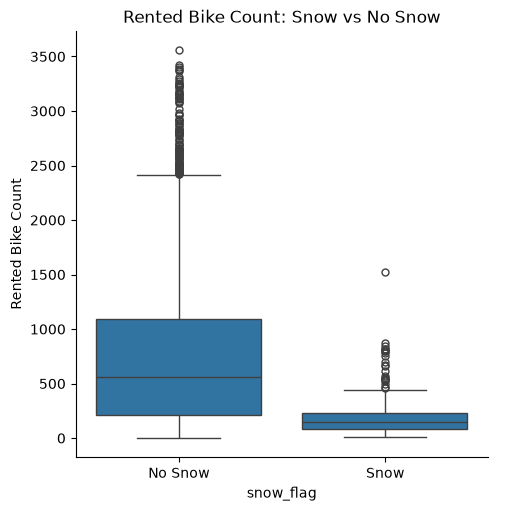

In [45]:

sns.catplot(x='snow_flag', y='Rented Bike Count', data=data, kind='box', height=5, aspect=1)
plt.title('Rented Bike Count: Snow vs No Snow')
plt.show()

In [46]:
cat_cols = data.select_dtypes(include='object').columns
print(cat_cols)
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)


Index(['Seasons', 'Holiday', 'Functioning Day', 'weekday', 'rain_flag',
       'snow_flag'],
      dtype='str')


/var/folders/f7/6ttbslv14mb1smgbhyrcq1xh0000gn/T/ipykernel_13304/2542286236.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = data.select_dtypes(include='object').columns


In [47]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Date                       8760 non-null   datetime64[us]
 1   Rented Bike Count          8760 non-null   int64         
 2   Hour                       8760 non-null   int64         
 3   Temperature(�C)            8760 non-null   float64       
 4   Humidity(%)                8760 non-null   int64         
 5   Wind speed (m/s)           8760 non-null   float64       
 6   Visibility (10m)           8760 non-null   int64         
 7   Dew point temperature(�C)  8760 non-null   float64       
 8   Solar Radiation (MJ/m2)    8760 non-null   float64       
 9   Rainfall(mm)               8760 non-null   float64       
 10  Snowfall (cm)              8760 non-null   float64       
 11  day                        8760 non-null   int32         
 12  year             

In [48]:
data.head()

,Date,Rented Bike Count,Hour,Temperature(�C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(�C),Solar Radiation (MJ/m2),Rainfall(mm),...,Holiday_No Holiday,Functioning Day_Yes,weekday_Monday,weekday_Saturday,weekday_Sunday,weekday_Thursday,weekday_Tuesday,weekday_Wednesday,rain_flag_Rain,snow_flag_Snow
0,2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,...,True,True,False,False,False,False,False,False,False,False
1,2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,...,True,True,False,False,False,False,False,False,False,False
2,2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,...,True,True,False,False,False,False,False,False,False,False
3,2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,...,True,True,False,False,False,False,False,False,False,False
4,2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,...,True,True,False,False,False,False,False,False,False,False


In [49]:
cat_cols = data.select_dtypes(include='object').columns
print(cat_cols)  
data = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=int)
# data = pd.get_dummies(data, columns=cat_cols, drop_first=True, dtype=int)
# bool_cols = data.select_dtypes(include='bool').columns
# data[bool_cols] = data[bool_cols].astype(int)
# data.head(5)

Index([], dtype='str')


In [50]:
# ! pip install scikit-learn
 

In [51]:
from sklearn.model_selection import train_test_split
X = data.drop(['Rented Bike Count', 'Date'], axis=1)
y = data['Rented Bike Count']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [52]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(7008, 26) (1752, 26) (7008,) (1752,)


In [53]:
# ! pip install StandardScaler

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)


In [55]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [56]:
X_test_scaled = scaler.transform(X_test)


In [57]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
lr = LinearRegression().fit(X_train_scaled, y_train)
lasso = Lasso(alpha=1.0).fit(X_train_scaled, y_train)
ridge = Ridge(alpha=1.0).fit(X_train_scaled, y_train)

In [58]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_lasso = lasso.predict(X_test_scaled)
y_pred_ridge = ridge.predict(X_test_scaled)

In [59]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

def evaluate(name, y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{name}: R2={r2:.3f}, RMSE={rmse:.2f}, MAE={mae:.2f}")

evaluate("Linear Regression", y_test, y_pred_lr)
evaluate("Lasso", y_test, y_pred_lasso)
evaluate("Ridge", y_test, y_pred_ridge)
 

Linear Regression: R2=0.563, RMSE=426.71, MAE=320.25
Lasso: R2=0.563, RMSE=426.47, MAE=319.36
Ridge: R2=0.563, RMSE=426.69, MAE=320.20


,R2,RMSE,MAE
Model,,,
Linear Regression,0.562975,426.714189,320.245959
Lasso,0.563485,426.465106,319.363730
Ridge,0.563030,426.686985,320.195052


Best model by RMSE: Lasso


,Actual,Linear Regression,Lasso,Ridge
0,1728,985.351133,1004.998765,986.271981
1,822,1184.159765,1188.046264,1184.751357
2,658,1347.808340,1374.528660,1348.577712
3,2716,1347.040516,1335.551211,1346.731792
4,1083,588.519617,590.211676,588.809142
5,636,716.091331,719.174044,716.168013
6,1537,1486.990191,1508.804559,1487.659071
7,712,1057.286831,1077.994233,1058.085328
8,425,924.057539,951.423433,924.911928
9,594,887.735326,845.276766,886.752069


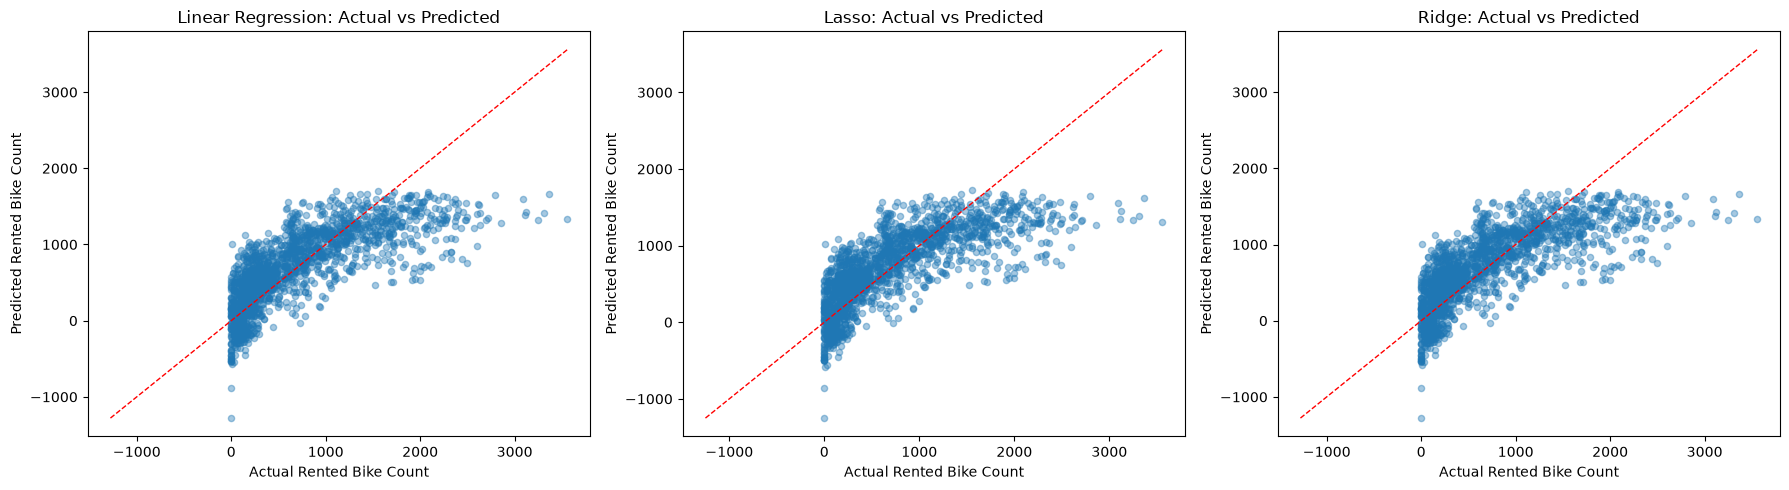

In [60]:
# Generate a concise report for the three regression models
results = []
for name, y_pred in [
    ("Linear Regression", y_pred_lr),
    ("Lasso", y_pred_lasso),
    ("Ridge", y_pred_ridge),
]:
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    results.append({
        "Model": name,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

report_df = pd.DataFrame(results).set_index("Model")
display(report_df)

best_model = report_df["RMSE"].idxmin()
print(f"Best model by RMSE: {best_model}")

comparison = pd.DataFrame({
    "Actual": y_test.reset_index(drop=True),
    "Linear Regression": y_pred_lr,
    "Lasso": y_pred_lasso,
    "Ridge": y_pred_ridge
}).head(10)
display(comparison)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, y_pred) in zip(axes, [
    ("Linear Regression", y_pred_lr),
    ("Lasso", y_pred_lasso),
    ("Ridge", y_pred_ridge),
]):
    ax.scatter(y_test, y_pred, alpha=0.4, s=20)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1)
    ax.set_title(f"{name}: Actual vs Predicted")
    ax.set_xlabel("Actual Rented Bike Count")
    ax.set_ylabel("Predicted Rented Bike Count")
plt.tight_layout()
plt.show()